In [ ]:
#Part A — Data preparation

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [53]:
sentiment = pd.read_csv(r"C:\Users\mg443\Downloads\fear_greed_index.csv")
trades = pd.read_csv(r"C:\Users\mg443\Downloads\historical_data.csv")

In [54]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [55]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [56]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [57]:
print("Sentiment Columns:")
print(sentiment.columns.tolist())

print("\nTrades Columns:")
print(trades.columns.tolist())

Sentiment Columns:
['timestamp', 'value', 'classification', 'date']

Trades Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [58]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [59]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [60]:
print("Sentiment Missing Values")
print(sentiment.isnull().sum())

print("\nTrades Missing Values")
print(trades.isnull().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [61]:
print("Sentiment Duplicate Rows:", sentiment.duplicated().sum())

print("Trades Duplicate Rows:", trades.duplicated().sum())

Sentiment Duplicate Rows: 0
Trades Duplicate Rows: 0


In [62]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

In [63]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [64]:
sentiment["Date"] = sentiment["date"].dt.date

trades["Date"] = trades["Timestamp IST"].dt.date

In [65]:
print(sentiment[["date", "Date"]].head())

        date        Date
0 2018-02-01  2018-02-01
1 2018-02-02  2018-02-02
2 2018-02-03  2018-02-03
3 2018-02-04  2018-02-04
4 2018-02-05  2018-02-05


In [66]:
print(trades[["Timestamp IST", "Date"]].head())

        Timestamp IST        Date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [67]:
merged = pd.merge(
    trades,
    sentiment[["Date", "classification"]],
    on="Date",
    how="left"
)

In [68]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [69]:
merged.shape

(211224, 18)

In [70]:
merged["classification"].value_counts(dropna=False)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64

In [71]:
daily_pnl = (
    merged.groupby(["Account", "Date"])["Closed PnL"]
    .sum()
    .reset_index()
)
daily_pnl.head()

,Account,Date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [72]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate = (
    merged.groupby("Account")["Win"]
    .mean()
    .reset_index()
)

win_rate["Win"] = win_rate["Win"] * 100
win_rate.rename(columns={"Win":"Win Rate (%)"}, inplace=True)
win_rate.head()

,Account,Win Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355


In [73]:
avg_trade_size = (
    merged.groupby("Account")["Size USD"]
    .mean()
    .reset_index()
)
avg_trade_size.rename(
    columns={"Size USD":"Average Trade Size (USD)"},
    inplace=True
)
avg_trade_size.head()

,Account,Average Trade Size (USD)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [74]:
trades_per_day = (
    merged.groupby("Date")
    .size()
    .reset_index(name="Number of Trades")
)
trades_per_day.head()

,Date,Number of Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [75]:
long_short_ratio = (
    merged["Side"]
    .value_counts(normalize=True)
    * 100
)
print(long_short_ratio)

Side
SELL    51.380525
BUY     48.619475
Name: proportion, dtype: float64


In [76]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'classification', 'Win']


In [77]:
#Part B — Analysis
#1.Does performance (PnL, Win Rate) differ between Fear vs Greed days?

In [78]:
pnl_by_sentiment = (
    merged.groupby("classification")["Closed PnL"]
    .agg(["mean", "median", "sum", "count"])
    .round(2)
)

print(pnl_by_sentiment)

                 mean  median         sum  count
classification                                  
Extreme Fear    34.54     0.0   739110.25  21400
Extreme Greed   67.89     0.0  2715171.31  39992
Fear            54.29     0.0  3357155.44  61837
Greed           42.74     0.0  2150129.27  50303
Neutral         34.31     0.0  1292920.68  37686


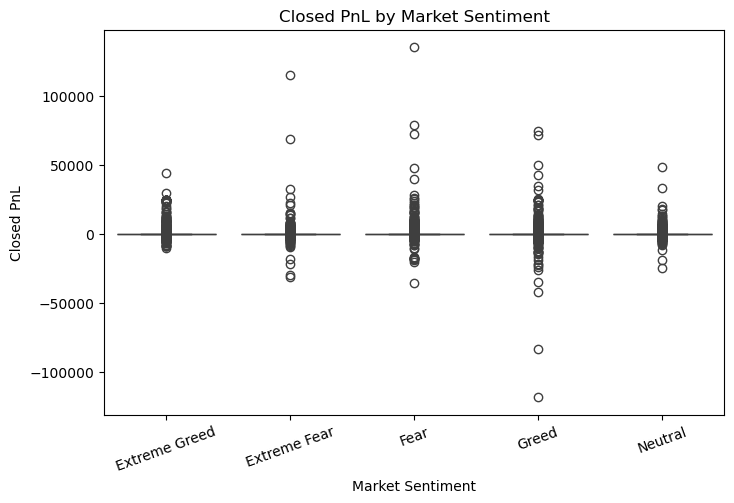

In [79]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)
plt.title("Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.xticks(rotation=20)
plt.show()

In [29]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate = (
    merged.groupby("classification")["Win"]
    .mean()
    * 100
).round(2)

print(win_rate)

classification
Extreme Fear     37.06
Extreme Greed    46.49
Fear             42.08
Greed            38.48
Neutral          39.70
Name: Win, dtype: float64


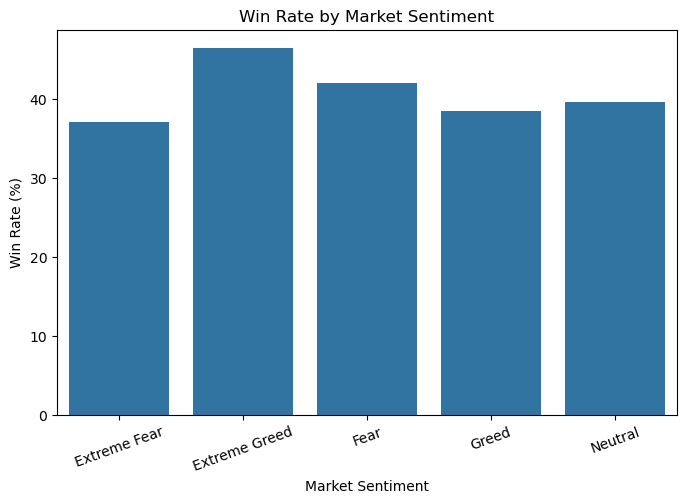

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=win_rate.index,
    y=win_rate.values
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=20)

plt.show()

In [ ]:
#2. Do traders change behavior based on sentiment?

In [31]:
trade_frequency = (
    merged.groupby("classification")
    .size()
    .reset_index(name="Trades")
)

print(trade_frequency)

  classification  Trades
0   Extreme Fear   21400
1  Extreme Greed   39992
2           Fear   61837
3          Greed   50303
4        Neutral   37686


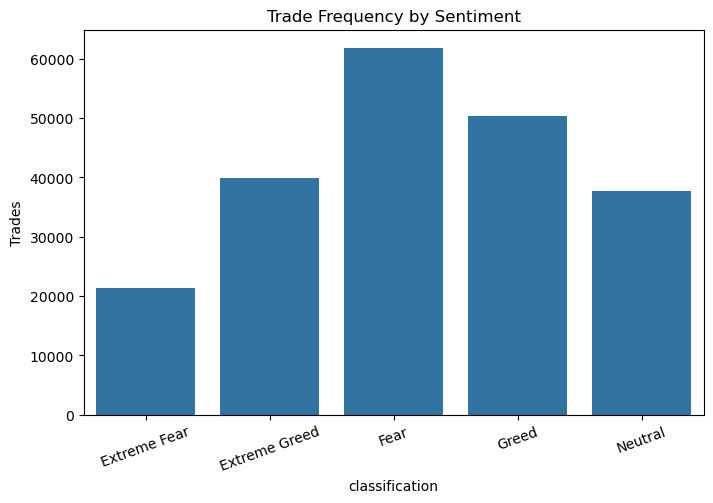

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_frequency,
    x="classification",
    y="Trades"
)

plt.title("Trade Frequency by Sentiment")
plt.xticks(rotation=20)
plt.show()

In [33]:
position_size = (
    merged.groupby("classification")["Size USD"]
    .mean()
    .round(2)
)

print(position_size)

classification
Extreme Fear     5349.73
Extreme Greed    3112.25
Fear             7816.11
Greed            5736.88
Neutral          4782.73
Name: Size USD, dtype: float64


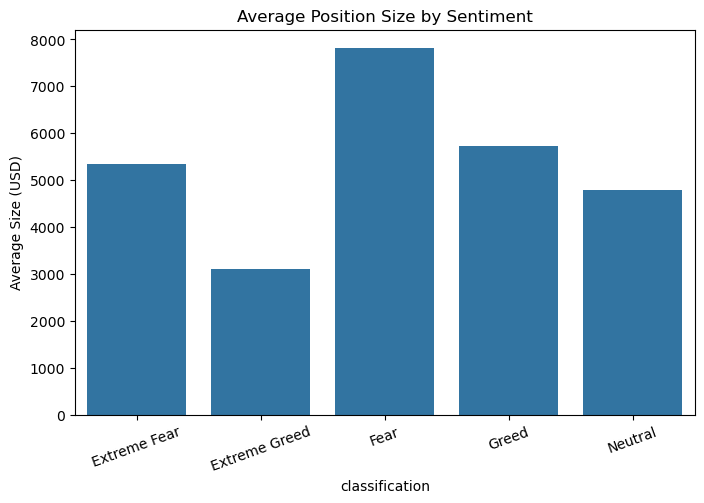

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=position_size.index,
    y=position_size.values
)

plt.title("Average Position Size by Sentiment")
plt.ylabel("Average Size (USD)")
plt.xticks(rotation=20)

plt.show()

In [35]:
long_short = pd.crosstab(
    merged["classification"],
    merged["Side"],
    normalize="index"
) * 100

print(long_short)

Side                  BUY       SELL
classification                      
Extreme Fear    51.098131  48.901869
Extreme Greed   44.858972  55.141028
Fear            48.951275  51.048725
Greed           48.855933  51.144067
Neutral         50.334342  49.665658


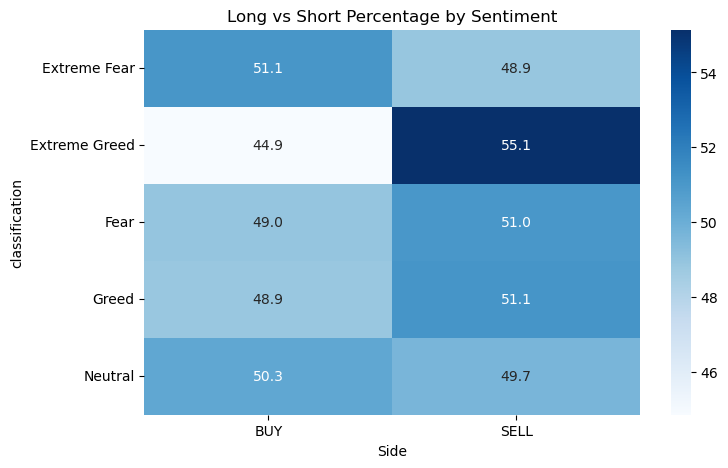

In [36]:
plt.figure(figsize=(8,5))

sns.heatmap(
    long_short,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Long vs Short Percentage by Sentiment")

plt.show()

In [ ]:
#3. Trader Segmentation

In [37]:
trade_count = (
    merged.groupby("Account")
    .size()
    .reset_index(name="Trades")
)

median_trades = trade_count["Trades"].median()

trade_count["Segment"] = np.where(
    trade_count["Trades"] >= median_trades,
    "Frequent",
    "Infrequent"
)

trade_count.head()

,Account,Trades,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent


In [38]:
win_rate_account = (
    merged.groupby("Account")["Win"]
    .mean()
    .reset_index()
)

win_rate_account["Win"] *= 100

win_rate_account["Segment"] = np.where(
    win_rate_account["Win"] >= 60,
    "Consistent Winner",
    "Others"
)

win_rate_account.head()

,Account,Win,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236,Others
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978,Others
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651,Others
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463,Others
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355,Others


In [39]:
avg_size = (
    merged.groupby("Account")["Size USD"]
    .mean()
    .reset_index()
)

median_size = avg_size["Size USD"].median()

avg_size["Segment"] = np.where(
    avg_size["Size USD"] >= median_size,
    "Large Position",
    "Small Position"
)

avg_size.head()

,Account,Size USD,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734,Large Position
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327,Small Position
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898,Large Position
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933,Small Position
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782,Small Position


In [ ]:
#Insight 1: Performance by Market Sentiment

In [40]:
pnl_summary = merged.groupby("classification")["Closed PnL"].agg(
    Total_PnL="sum",
    Average_PnL="mean",
    Median_PnL="median",
    Trades="count"
).round(2)

print(pnl_summary)

                 Total_PnL  Average_PnL  Median_PnL  Trades
classification                                             
Extreme Fear     739110.25        34.54         0.0   21400
Extreme Greed   2715171.31        67.89         0.0   39992
Fear            3357155.44        54.29         0.0   61837
Greed           2150129.27        42.74         0.0   50303
Neutral         1292920.68        34.31         0.0   37686


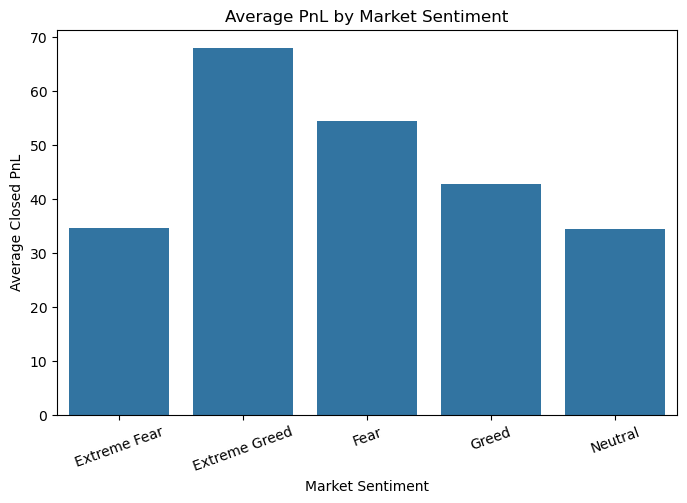

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=pnl_summary.reset_index(),
    x="classification",
    y="Average_PnL"
)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=20)
plt.show()

In [ ]:
#Insight 2: Trading Activity Changes with Sentiment

In [42]:
trade_freq = merged.groupby("classification").size().reset_index(name="Trades")
print(trade_freq)

  classification  Trades
0   Extreme Fear   21400
1  Extreme Greed   39992
2           Fear   61837
3          Greed   50303
4        Neutral   37686


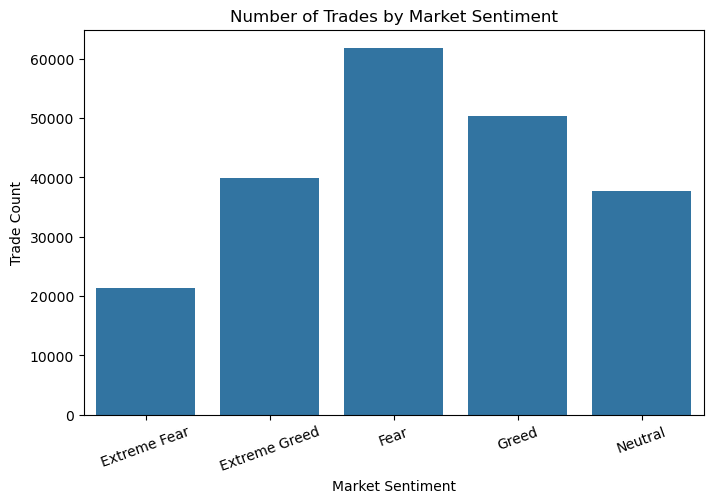

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=trade_freq,
    x="classification",
    y="Trades"
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")
plt.xticks(rotation=20)
plt.show()

In [ ]:
#Insight 3: Position Size and Long/Short Behaviour

In [44]:
position_size = merged.groupby("classification")["Size USD"].mean().round(2)

print(position_size)

classification
Extreme Fear     5349.73
Extreme Greed    3112.25
Fear             7816.11
Greed            5736.88
Neutral          4782.73
Name: Size USD, dtype: float64


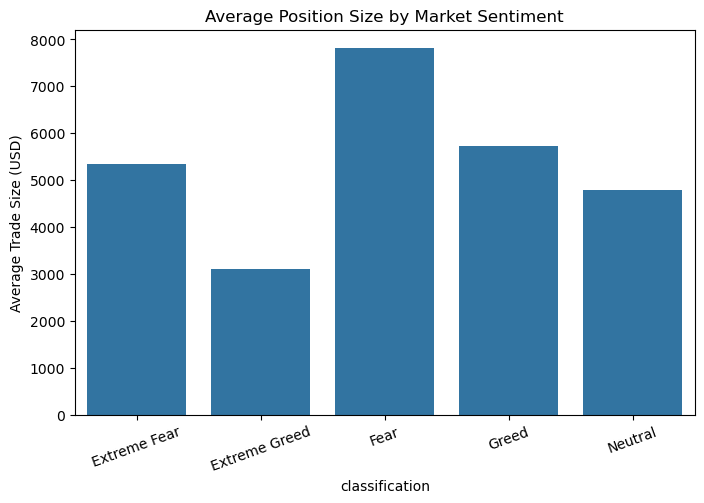

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=position_size.index,
    y=position_size.values
)

plt.title("Average Position Size by Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=20)
plt.show()

In [46]:
long_short = pd.crosstab(
    merged["classification"],
    merged["Side"],
    normalize="index"
) * 100

print(long_short)

Side                  BUY       SELL
classification                      
Extreme Fear    51.098131  48.901869
Extreme Greed   44.858972  55.141028
Fear            48.951275  51.048725
Greed           48.855933  51.144067
Neutral         50.334342  49.665658


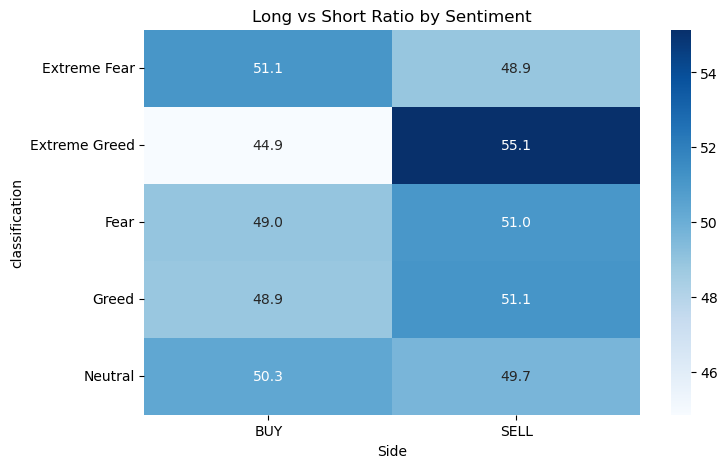

In [47]:
plt.figure(figsize=(8,5))

sns.heatmap(long_short,
            annot=True,
            fmt=".1f",
            cmap="Blues")

plt.title("Long vs Short Ratio by Sentiment")
plt.show()

In [ ]:
#Part C – Actionable Output
Strategy 1: Risk-Based Position Sizing During Fear Markets

Rule of Thumb:
During Fear and Extreme Fear market conditions, traders should reduce position sizes and avoid excessive trading. If the analysis shows lower average PnL or win rates on Fear days, using smaller positions can help limit losses and preserve capital during uncertain markets.
Supported by:
PnL by Market Sentiment chart
Average Position Size by Sentiment chart
    
Strategy 2: Increase Exposure During Greed Markets (With Risk Controls)

Rule of Thumb:
If Greed or Extreme Greed days demonstrate higher average profitability and win rates, traders may cautiously increase trade size or trading activity. However, predefined stop-loss levels and position limits should still be maintained to manage downside risk.
Supported by:
Win Rate by Sentiment chart
Trade Frequency by Sentiment chart

In [ ]:
#Predict Next-Day Profitability

In [48]:
daily = merged.groupby(["Account", "Date"]).agg({
    "Closed PnL": "sum",
    "Size USD": "mean",
    "Win": "mean"
}).reset_index()

daily["Profit"] = (daily["Closed PnL"] > 0).astype(int)

In [49]:
from sklearn.model_selection import train_test_split

X = daily[["Size USD", "Win"]]
y = daily["Profit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [50]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9466950959488273
